In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
shops = pd.read_csv('../../raw_data/shops.csv')
items = pd.read_csv('../../raw_data/items.csv')
item_categories = pd.read_csv('../../raw_data/item_categories.csv')
sales_train = pd.read_csv('../../raw_data/sales_train.csv')

In [4]:
shops.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   shop_name  60 non-null     str  
 1   shop_id    60 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [5]:
item_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_category_name  84 non-null     str  
 1   item_category_id    84 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.4 KB


In [6]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB


In [7]:
items['item_name'].nunique()

22170

In [8]:
items['item_category_id'].nunique()

84

In [9]:
sales_train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935849 non-null  str    
 1   date_block_num  2935849 non-null  int64  
 2   shop_id         2935849 non-null  int64  
 3   item_id         2935849 non-null  int64  
 4   item_price      2935849 non-null  float64
 5   item_cnt_day    2935849 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


In [10]:
sales_train.sample(5)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
2921673,08.10.2015,33,7,4872,1499.0,1.0
1711321,21.06.2014,17,25,2574,399.0,1.0
493041,06.05.2013,4,50,9486,399.0,1.0
761220,12.08.2013,7,51,3186,256.0,1.0
2647489,17.05.2015,28,48,15812,999.0,1.0


In [11]:
sales_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            str    
 1   date_block_num  int64  
 2   shop_id         int64  
 3   item_id         int64  
 4   item_price      float64
 5   item_cnt_day    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


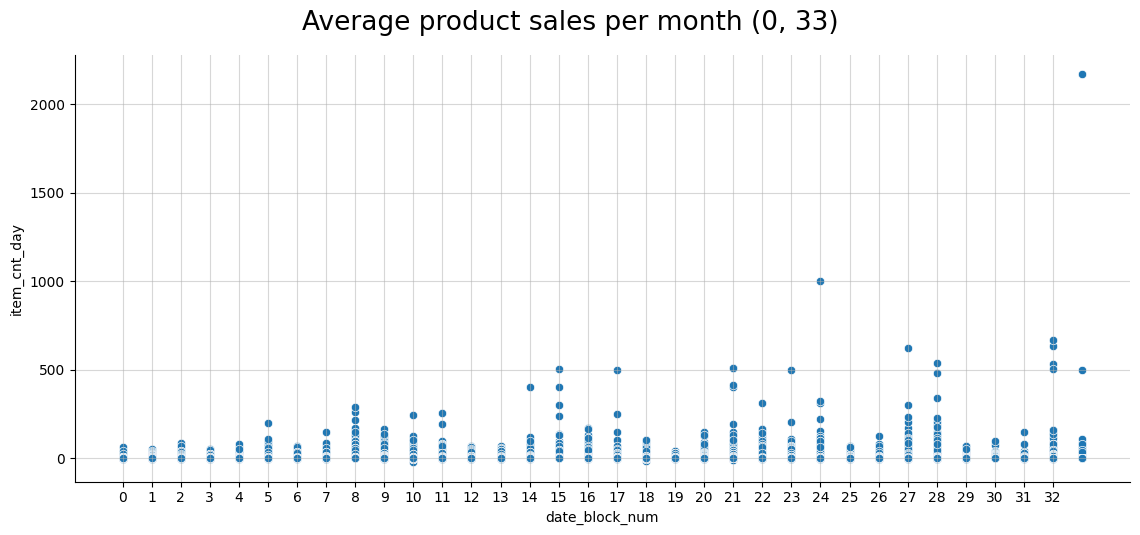

In [18]:
g = sns.relplot(
    data=sales_train,
    x='date_block_num',
    y='item_cnt_day',
    aspect=2.3,
    kind='scatter',
    marker='o',
    
);
g.figure.suptitle('Average product sales per month (0, 33)', y=1.06, fontsize=19)
g.set(xticks=range(33))
plt.grid(True, alpha=0.5);

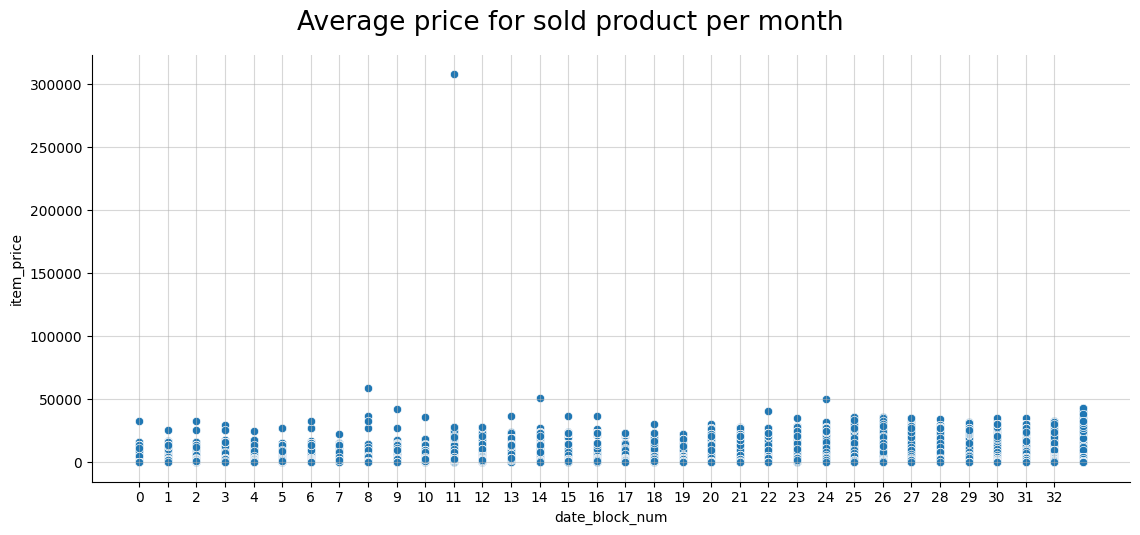

In [19]:
g = sns.relplot(
    data=sales_train,
    x='date_block_num',
    y='item_price',
    aspect=2.3,
    kind='scatter',
    marker='o',
    
);
g.figure.suptitle('Average price for sold product per month', y=1.06, fontsize=19)
g.set(xticks=range(33))
plt.grid(True, alpha=0.5) 

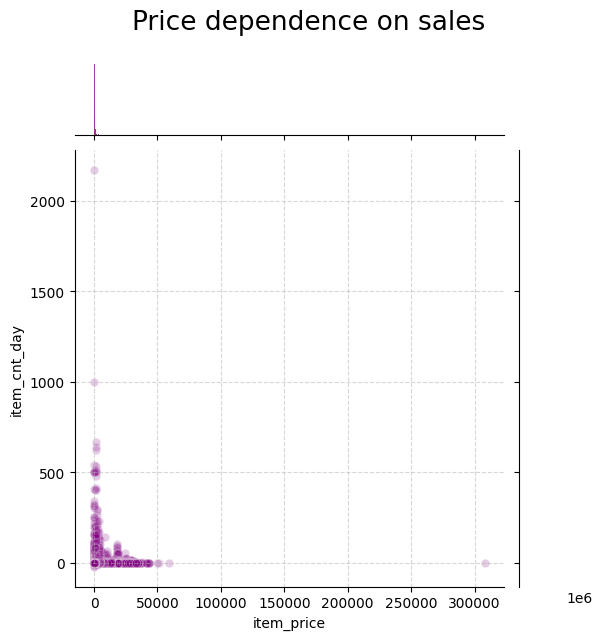

In [21]:
g = sns.jointplot(
    data=sales_train,
    x='item_price',
    y='item_cnt_day',
    kind='scatter',       
    alpha=0.2,            
    color='purple',
    height=6,
)
g.figure.suptitle('Price dependence on sales', y=1.06, fontsize=19)
g.ax_joint.grid(True, linestyle='--', alpha=0.5)

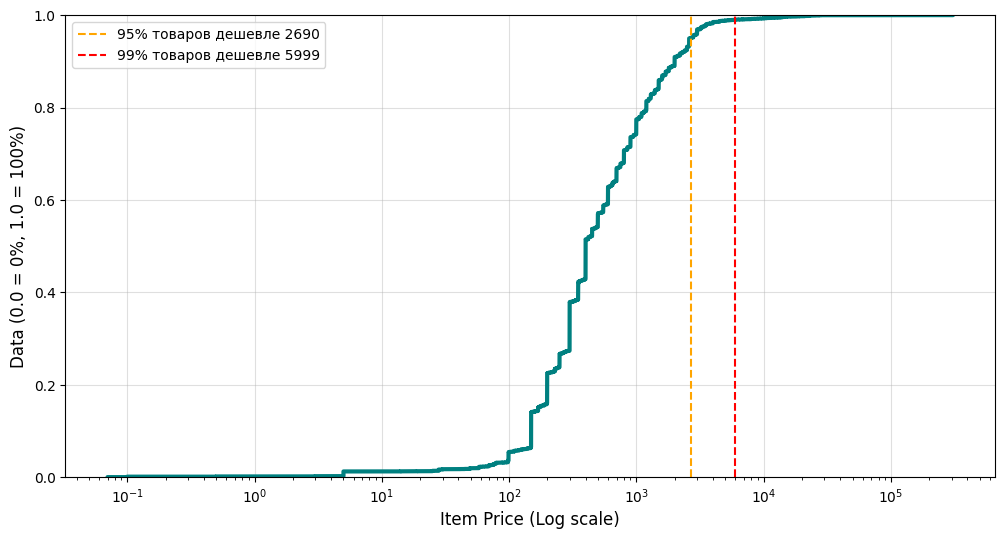

In [10]:
plt.figure(figsize=(12, 6))


sns.ecdfplot(
    data=sales_train, 
    x='item_price', 
    log_scale=True, 
    linewidth=3, 
    color='teal'
)

p95 = np.percentile(sales_train['item_price'], 95)
p99 = np.percentile(sales_train['item_price'], 99)

plt.axvline(p95, color='orange', linestyle='--', label=f'95% товаров дешевле {p95:.0f}')
plt.axvline(p99, color='red', linestyle='--', label=f'99% товаров дешевле {p99:.0f}')

plt.xlabel('Item Price (Log scale)', fontsize=12)
plt.ylabel('Data (0.0 = 0%, 1.0 = 100%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)


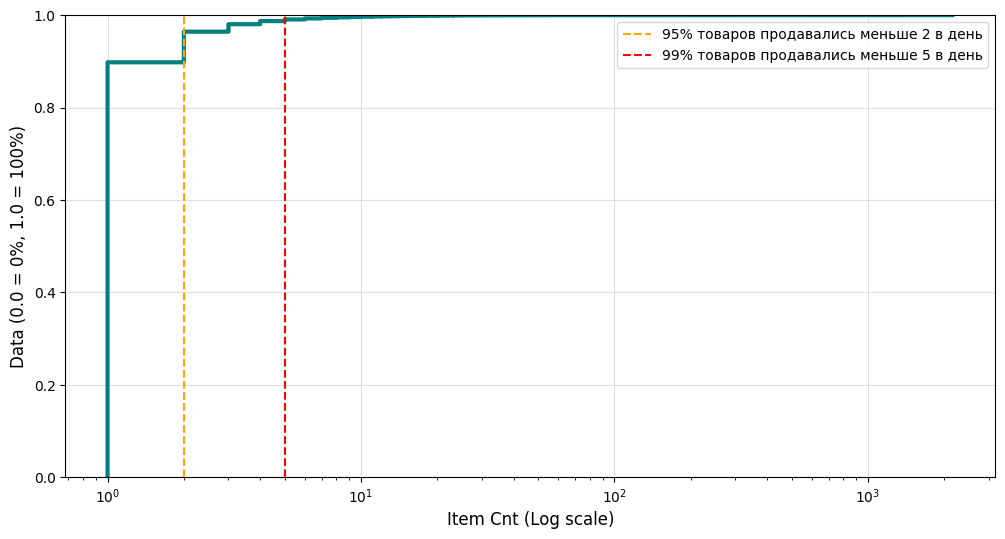

In [22]:
plt.figure(figsize=(12, 6))


sns.ecdfplot(
    data=sales_train, 
    x='item_cnt_day', 
    log_scale=True, 
    linewidth=3, 
    color='teal'
)

p95 = np.percentile(sales_train['item_cnt_day'], 95)
p99 = np.percentile(sales_train['item_cnt_day'], 99)

plt.axvline(p95, color='orange', linestyle='--', label=f'95% товаров продавались меньше {p95:.0f} в день')
plt.axvline(p99, color='red', linestyle='--', label=f'99% товаров продавались меньше {p99:.0f} в день')

plt.xlabel('Item Cnt (Log scale)', fontsize=12)
plt.ylabel('Data (0.0 = 0%, 1.0 = 100%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)

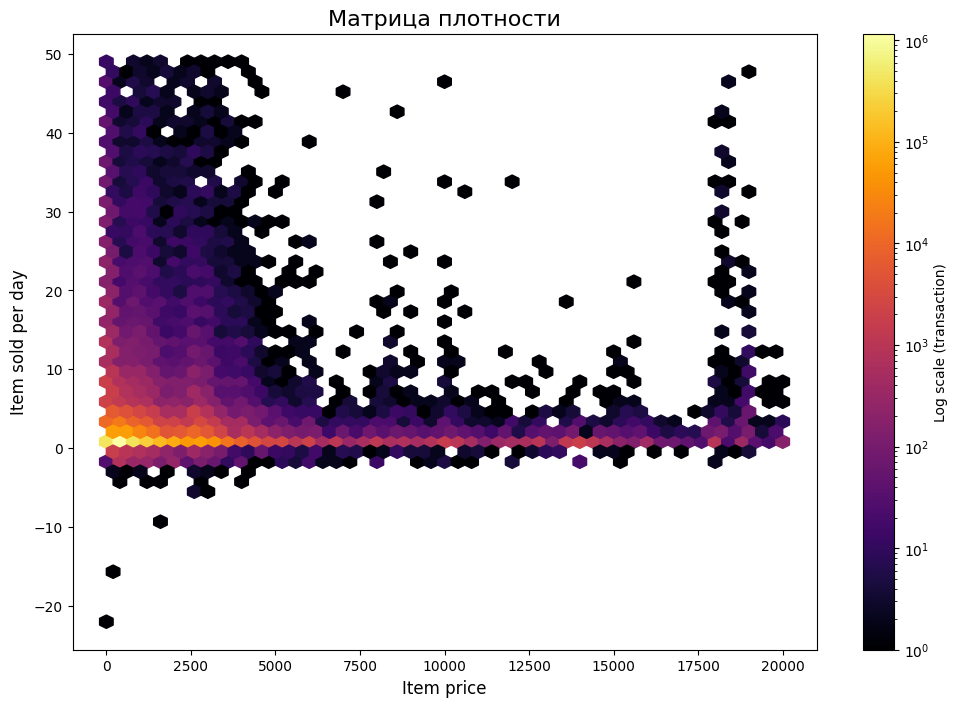

In [24]:
plt.figure(figsize=(12, 8))

visual_subset = sales_train[(sales_train['item_price'] < 20000) & (sales_train['item_cnt_day'] < 50)]

plt.hexbin(
    x=visual_subset['item_price'], 
    y=visual_subset['item_cnt_day'], 
    gridsize=50, 
    cmap='inferno', 
    bins='log',     
    mincnt=1        
)

plt.colorbar(label='Log scale (transaction)')
plt.title('Матрица плотности', fontsize=16)
plt.xlabel('Item price', fontsize=12)
plt.ylabel('Item sold per day', fontsize=12);


/var/folders/l8/512v7w716xq2l9fl947982sc0000gn/T/ipykernel_60317/3111955993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(


Text(0.5, 0, 'Item cnt in one transaction')

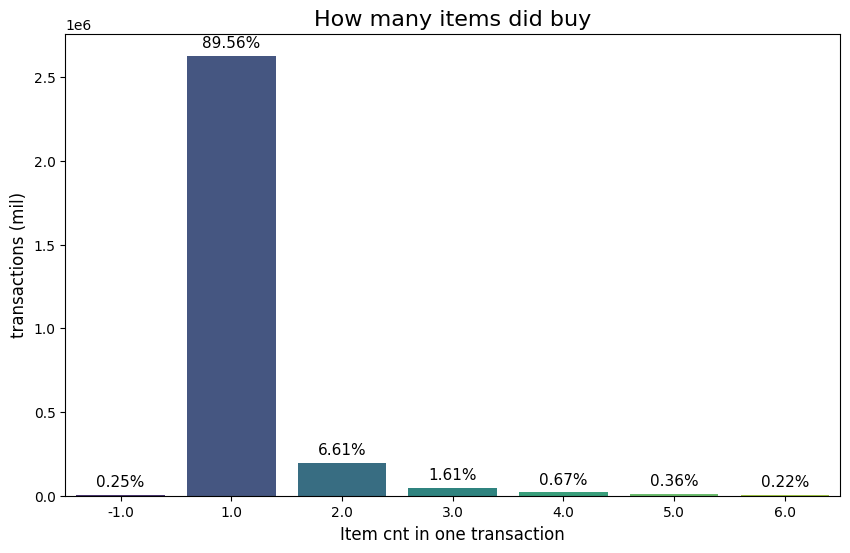

In [25]:


plt.figure(figsize=(10, 6))

value_counts = sales_train['item_cnt_day'].value_counts().nlargest(7).reset_index()
value_counts.columns = ['item_cnt_in_transaction', 'transaction_count']


g = sns.barplot(
    data=value_counts, 
    x='item_cnt_in_transaction', 
    y='transaction_count',
    palette='viridis'
);


total_transactions = len(sales_train)
for p in g.patches:
    height = p.get_height()
    percentage = f'{100 * height / total_transactions:.2f}%'
    g.text(p.get_x() + p.get_width()/2., height + 50000, percentage, ha="center", fontsize=11)

plt.title('How many items did buy', fontsize=16)
plt.ylabel('transactions (mil)', fontsize=12)
plt.xlabel('Item cnt in one transaction', fontsize=12)


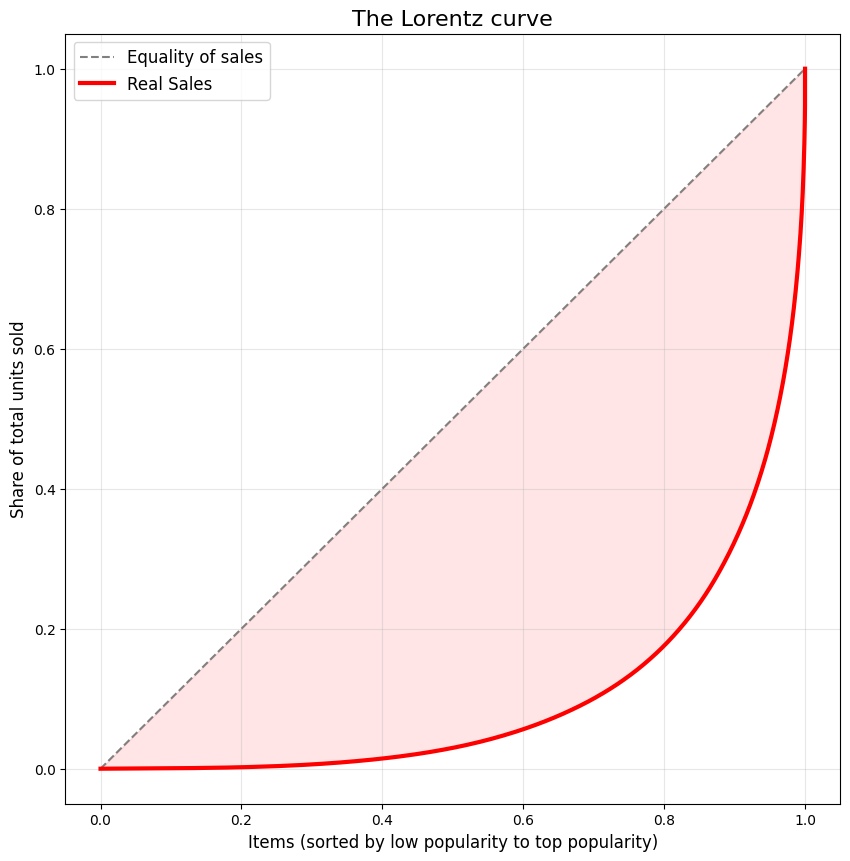

In [26]:
item_total_sales = sales_train.groupby('item_id')['item_cnt_day'].sum()


item_total_sales = item_total_sales[item_total_sales > 0].sort_values()

y_cumulative = np.cumsum(item_total_sales.values) / item_total_sales.sum()
x_cumulative = np.arange(1, len(item_total_sales) + 1) / len(item_total_sales)


plt.figure(figsize=(10, 10))

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Equality of sales')


plt.plot(x_cumulative, y_cumulative, color='red', linewidth=3, label='Real Sales')


plt.fill_between(x_cumulative, x_cumulative, y_cumulative, color='red', alpha=0.1)
plt.title('The Lorentz curve', fontsize=16)
plt.xlabel('Items (sorted by low popularity to top popularity)', fontsize=12)
plt.ylabel('Share of total units sold', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

значит, у нас куча слабого товара и парочка топовых

---

Возвраты

In [18]:
sales_train[sales_train['item_cnt_day'] < 0]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
2,05.01.2013,0,25,2552,899.0,-1.0
148,23.01.2013,0,25,2321,999.0,-1.0
175,07.01.2013,0,25,2199,1449.0,-1.0
807,02.01.2013,0,25,2330,599.0,-1.0
1041,13.01.2013,0,25,5034,1989.0,-1.0
...,...,...,...,...,...,...
2934243,26.10.2015,33,25,3917,449.0,-1.0
2934462,18.10.2015,33,25,4896,6398.0,-1.0
2935263,05.10.2015,33,25,10039,249.0,-1.0
2935643,16.10.2015,33,25,7893,2990.0,-1.0


In [66]:
sales_train[sales_train['item_price'] > 100000]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1163158,13.12.2013,11,12,6066,307980.0,1.0


In [67]:
sales_train[sales_train['item_cnt_day'] > 500]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1573253,22.04.2014,15,27,8057,1200.000000,502.0
1708207,28.06.2014,17,25,20949,5.000000,501.0
2048518,02.10.2014,21,12,9242,1500.000000,512.0
2067669,09.10.2014,21,55,19437,899.000000,508.0
2326930,15.01.2015,24,12,20949,4.000000,1000.0
2608040,14.04.2015,27,12,3731,1904.548077,624.0
2626181,19.05.2015,28,12,11373,155.192950,539.0
2851073,29.09.2015,32,55,9249,1500.000000,533.0
2851091,30.09.2015,32,55,9249,1702.825746,637.0
2864235,30.09.2015,32,12,9248,1692.526158,669.0
